# Group Work - Advanced Data Analysis and Machine Learning 
**Topic:** NASA Turbofan Level A2  
**Team:** Ahson Anwaar, Ondřej Beneš, Dan Valníček  
**Date:** 11.9.2026

## Imports

In [510]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## Data loading
Loading all the data in the format specified by the attached dataset description.

In [511]:
columns = [
    "unit number",
    "time in cycles",
    "operational setting 1",
    "operational setting 2",
    "operational setting 3",

    "total temperature at fan inlet",
    "total temperature at LPC outlet",
    "total temperature at HPC outlet",
    "total temperature at LPT outlet",
    "pressure at fan inlet",
    "pressure at bypass duct",
    "total pressure at HPC outlet",
    "physical fan speed",
    "physical core speed",
    "engine pressure ratio",
    "static pressure at HPC outlet",
    "ratio of fuel flow to Ps30",
    "corrected fan speed",
    "corrected core speed",
    "bypass ratio",
    "burner fuel-air ratio",
    "bleed enthalpy",
    "demanded fan speed",
    "demanded corrected fan speed",
    "HPT coolant bleed",
    "LPT coolant bleed",
]

# Load all datasets
train = {}
test = {}
rul = {}

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    train[fd] = pd.read_csv(
        f"./data/train_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    test[fd] = pd.read_csv(
        f"./data/test_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    rul[fd] = pd.read_csv(
        f"./data/RUL_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=["RUL"],
    )


for fd in train:
    print(f"{fd}:")
    print(f"  Train: {train[fd].shape}")
    print(f"  Test:  {test[fd].shape}")
    print(f"  RUL:   {rul[fd].shape}")
    print()

print(train["FD001"].head())

FD001:
  Train: (20631, 26)
  Test:  (13096, 26)
  RUL:   (100, 1)

FD002:
  Train: (53759, 26)
  Test:  (33991, 26)
  RUL:   (259, 1)

FD003:
  Train: (24720, 26)
  Test:  (16596, 26)
  RUL:   (100, 1)

FD004:
  Train: (61249, 26)
  Test:  (41214, 26)
  RUL:   (248, 1)

   unit number  time in cycles  operational setting 1  operational setting 2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational setting 3  total temperature at fan inlet  \
0                  100.0                          518.67   
1                  100.0                          518.67   
2                  100.0                          518.67   
3      

## Exploration

### Initial data visualization

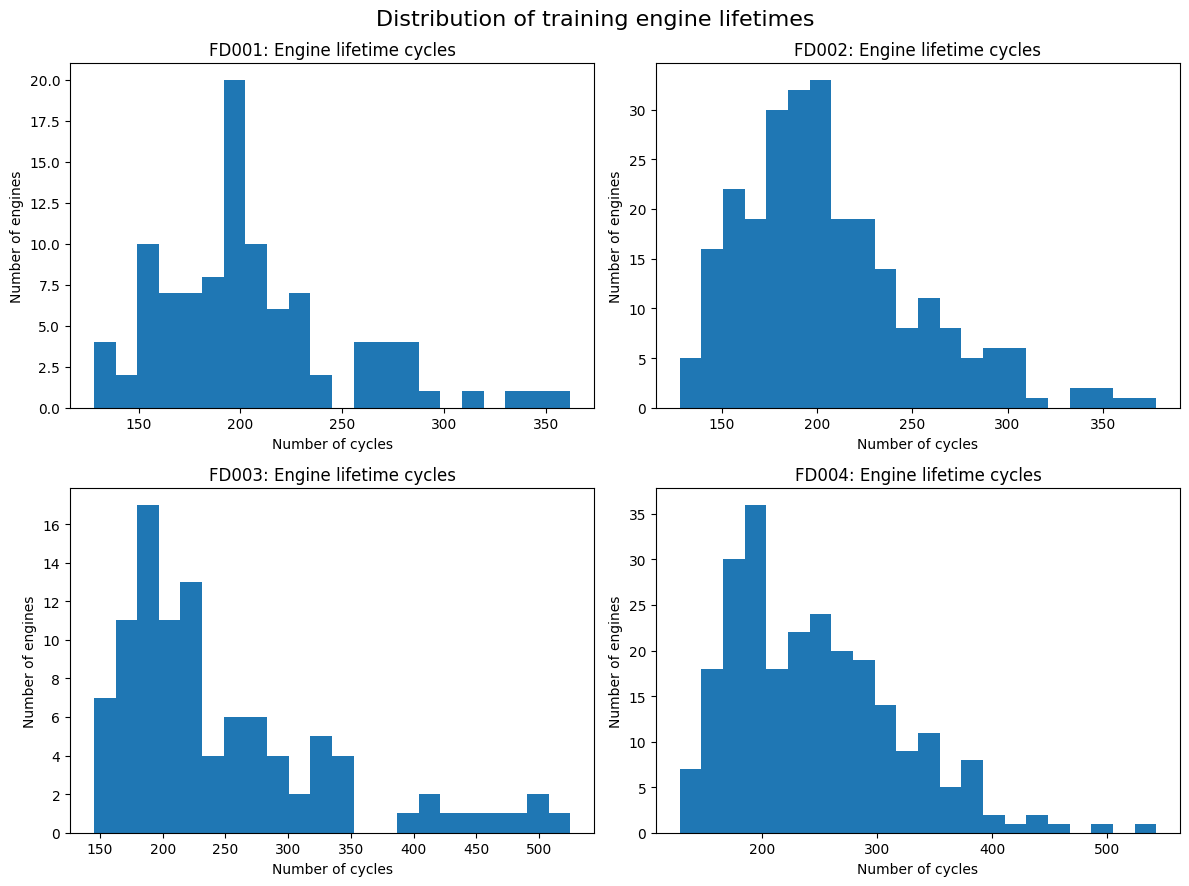

In [512]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    lifetime_cycles = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    axes[i].hist(
        lifetime_cycles,
        bins=22
    )

    axes[i].set_title(f"{fd}: Engine lifetime cycles")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel("Number of engines")

fig.suptitle(
    "Distribution of training engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()

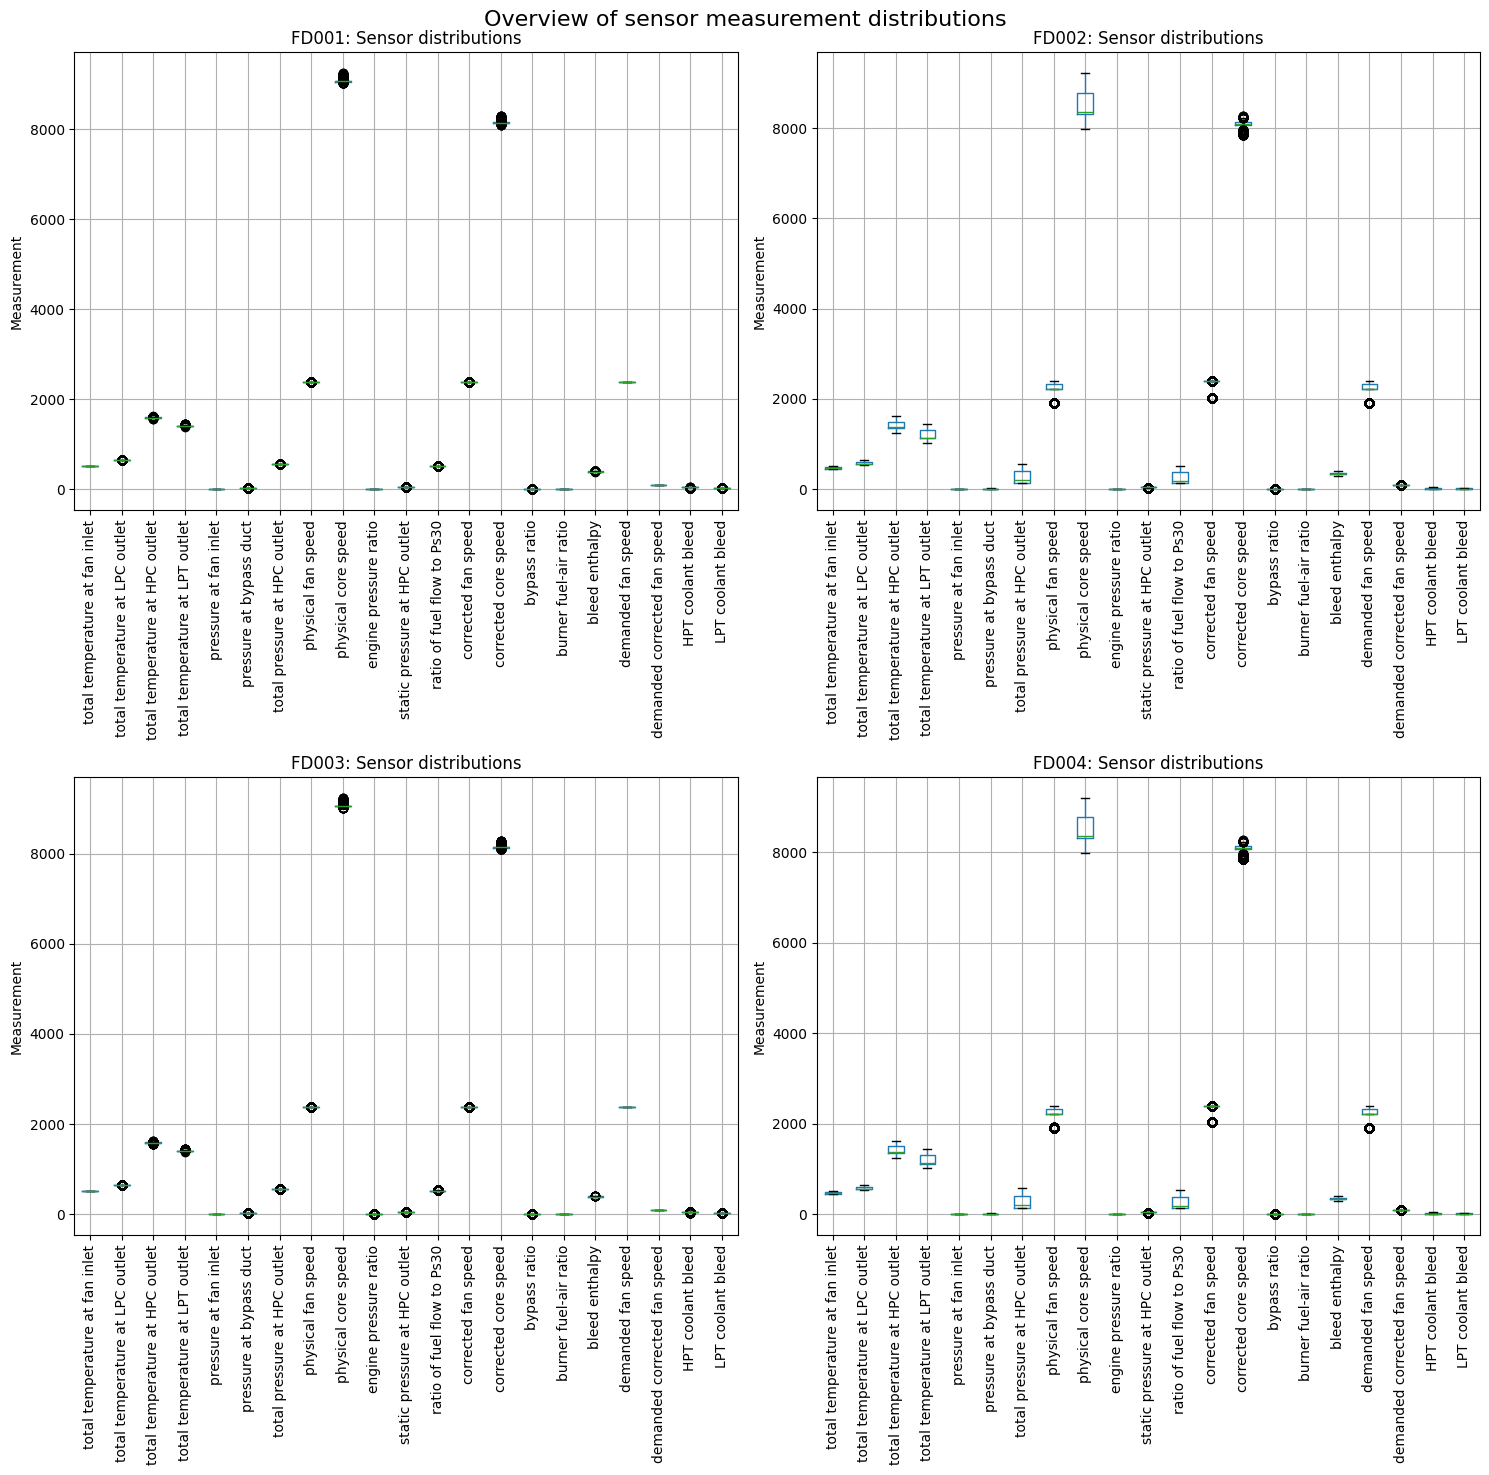

In [513]:
sensor_columns = columns[5:]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 15)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    train[fd][sensor_columns].boxplot(
        ax=axes[i]
    )

    axes[i].set_xticklabels(
        sensor_columns,
        rotation=90
    )

    axes[i].set_title(f"{fd}: Sensor distributions")
    axes[i].set_ylabel("Measurement")

fig.suptitle(
    "Overview of sensor measurement distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

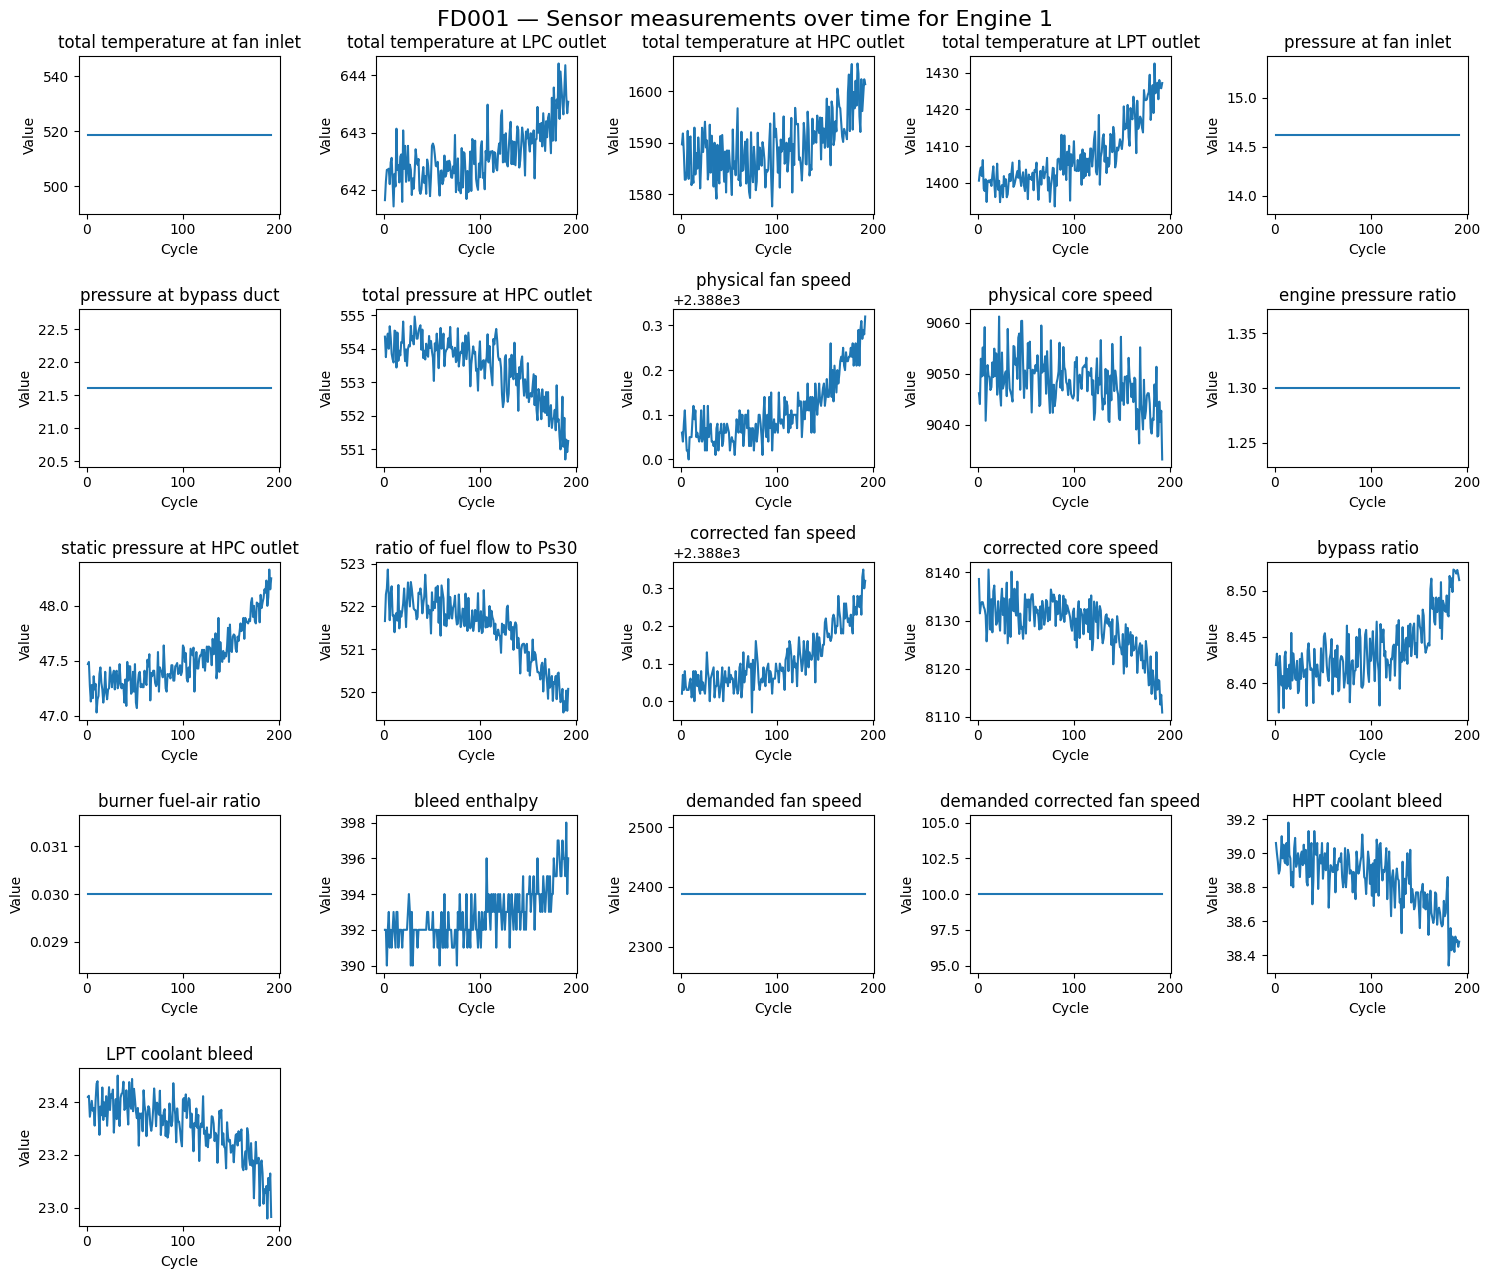

In [514]:
fd = "FD001"

engine = train[fd][
    train[fd]["unit number"] == 1
]

fig, axes = plt.subplots(
    5,
    5,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):

    axes[i].plot(
        engine["time in cycles"],
        engine[sensor]
    )

    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Value")

# Hide unused subplot
for i in range(len(sensor_columns), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "FD001 — Sensor measurements over time for Engine 1",
    fontsize=16
)

plt.tight_layout()
plt.show()

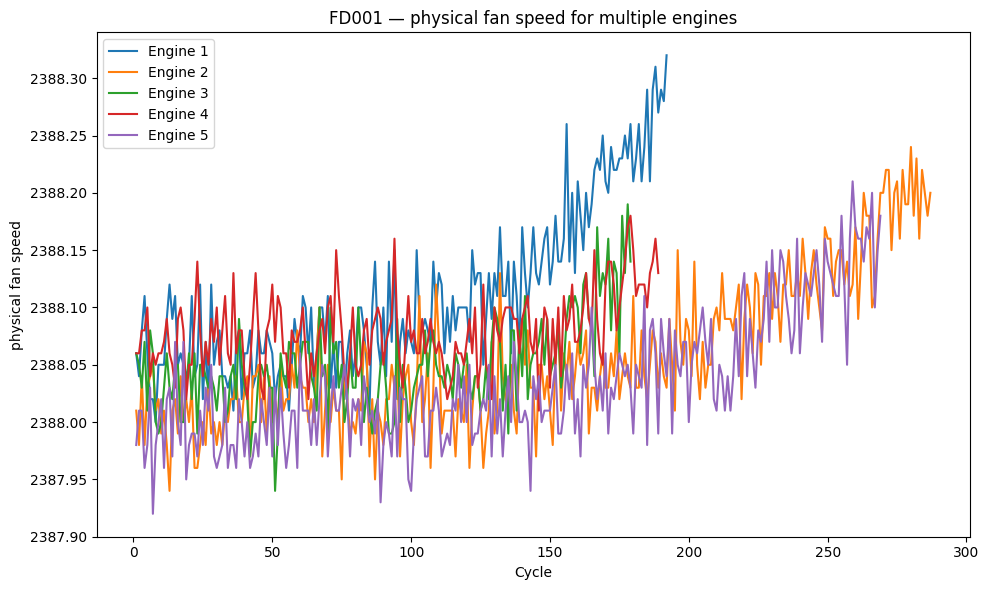

In [515]:
fd = "FD001"

plt.figure(figsize=(10, 6))

for unit in range(1,6):

    engine = train[fd][
        train[fd]["unit number"] == unit
    ]

    plt.plot(
        engine["time in cycles"],
        engine["physical fan speed"],
        label=f"Engine {unit}"
    )

plt.xlabel("Cycle")
plt.ylabel("physical fan speed")
plt.title(
    "FD001 — physical fan speed for multiple engines"
)

plt.legend()

plt.tight_layout()
plt.show()

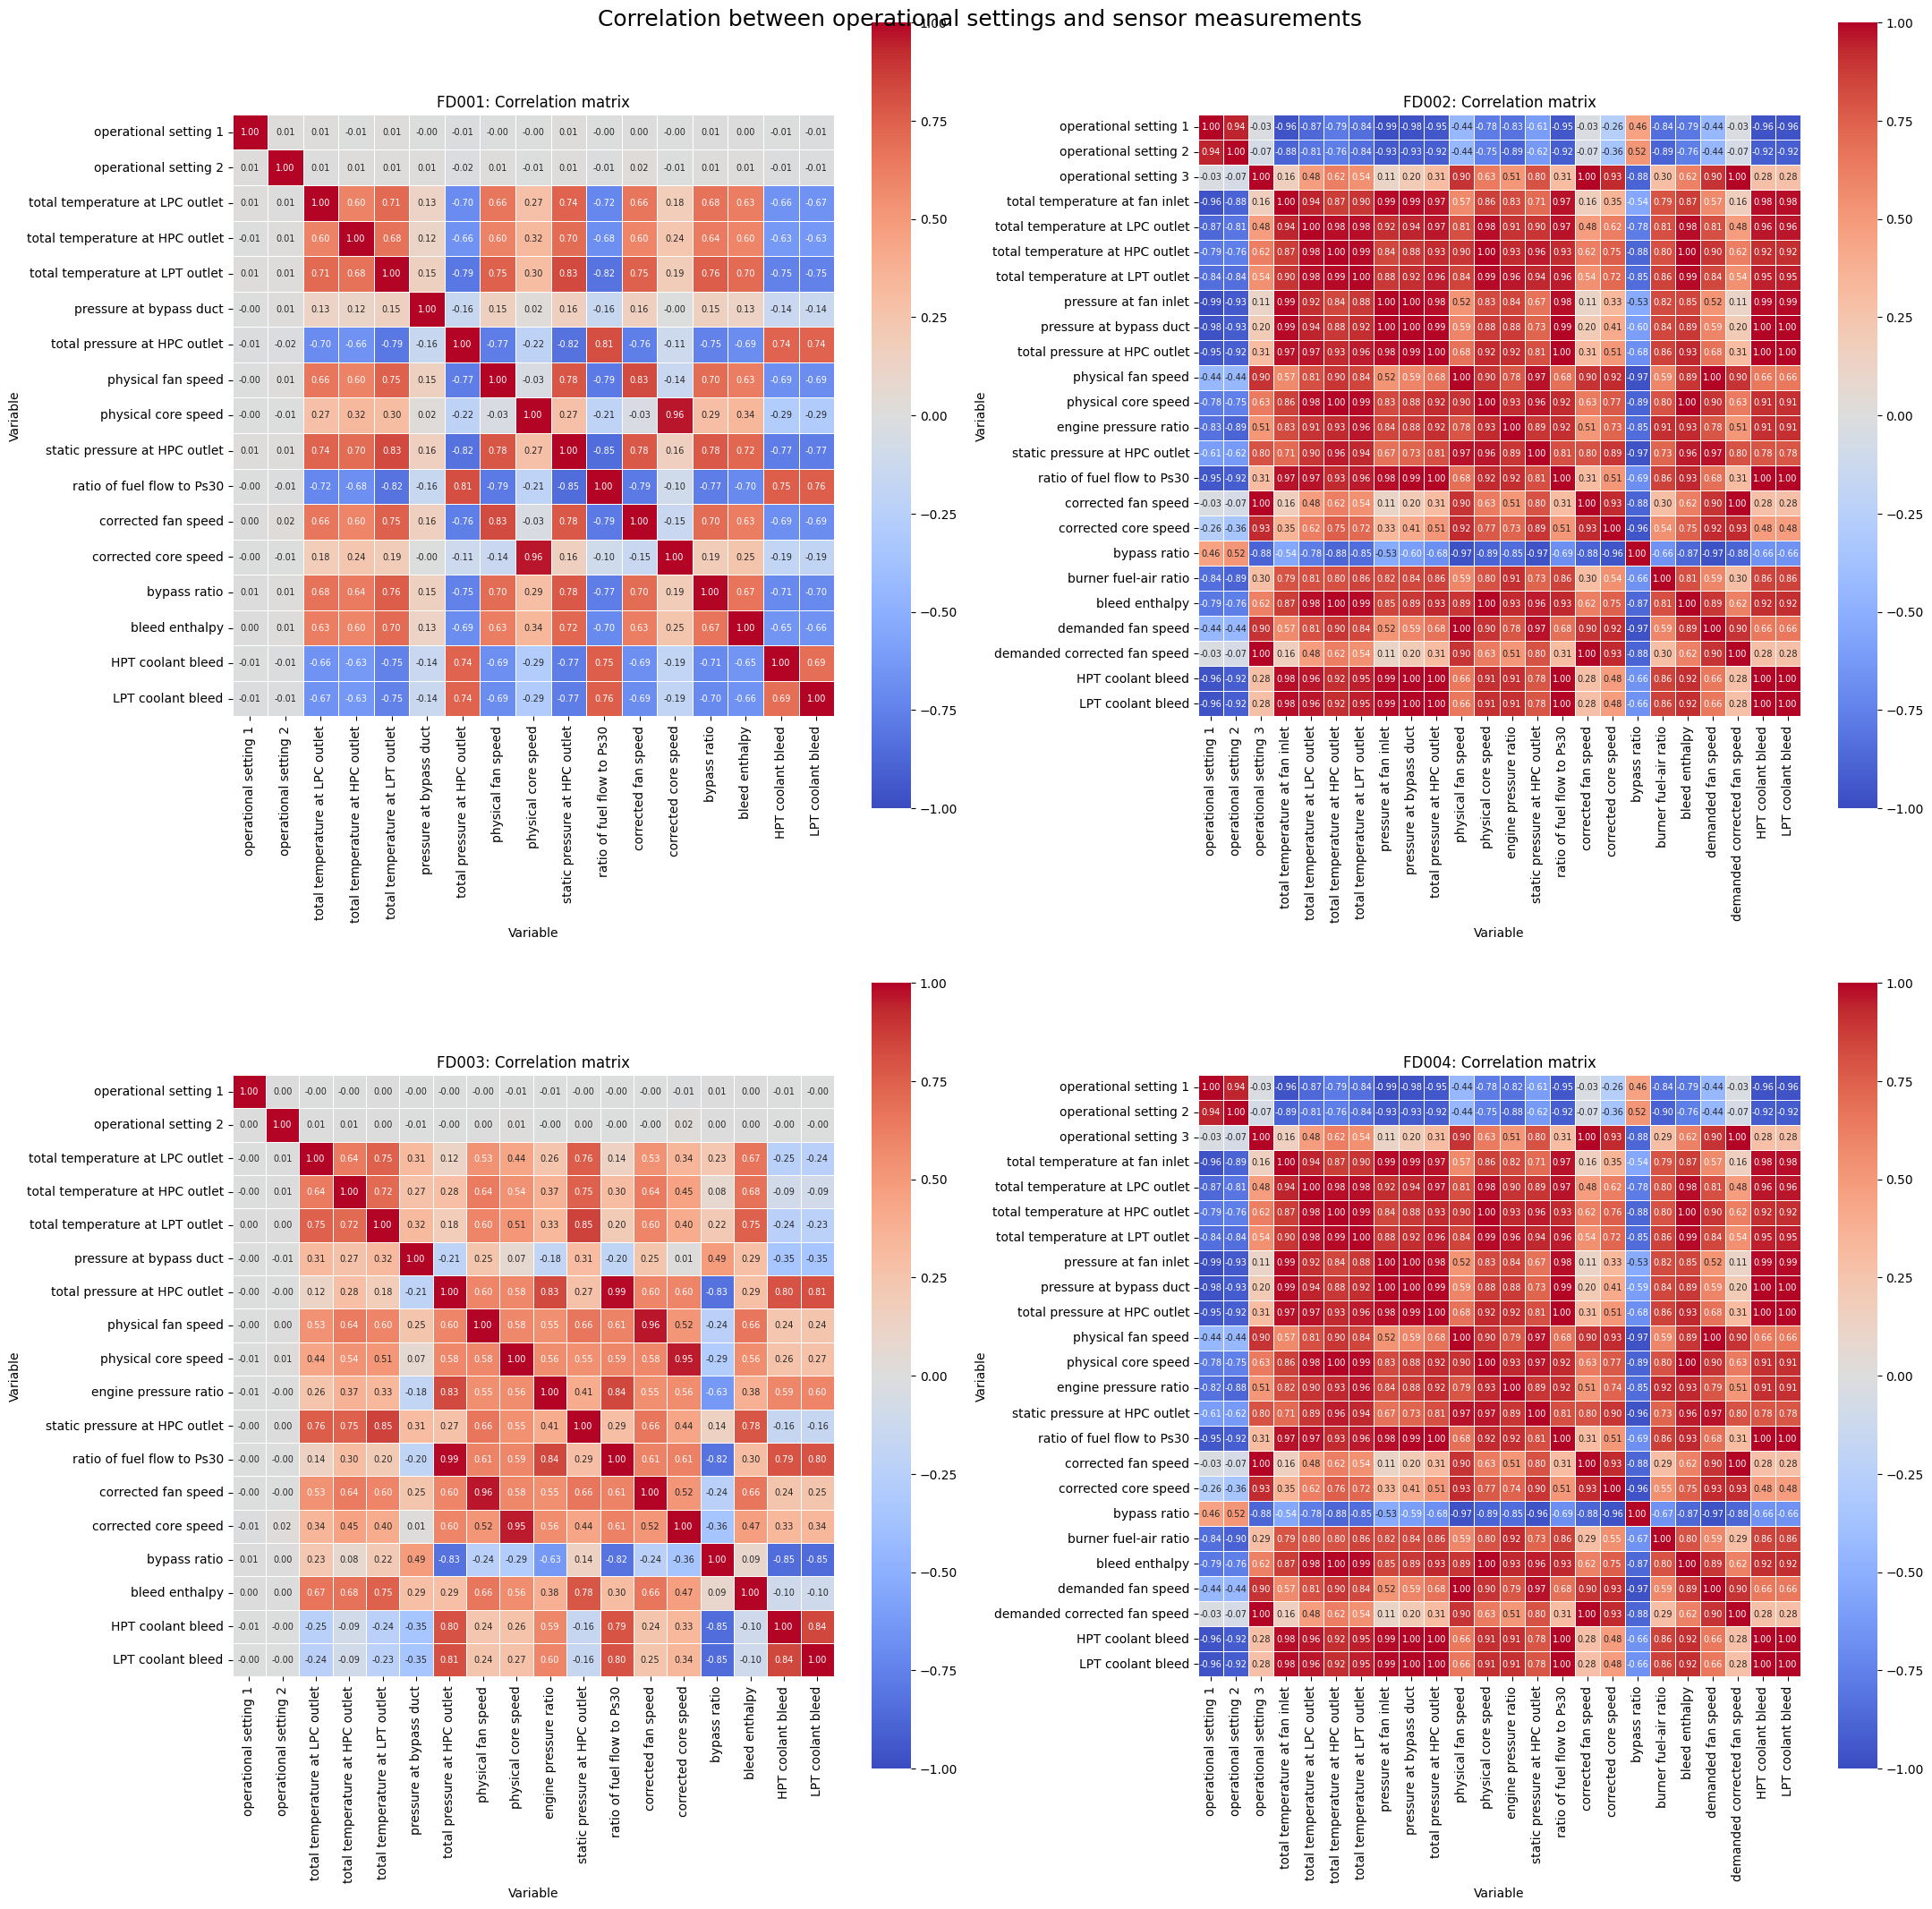

In [516]:
# Operational settings + 21 sensors
correlation_columns = columns[2:]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(22, 22)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    # Select operational settings + sensor measurements
    data = train[fd][correlation_columns]

    # Remove constant variables
    non_constant = data.loc[:, data.nunique() > 1]

    # Calculate correlation matrix
    correlation_matrix = non_constant.corr()

    sns.heatmap(
        correlation_matrix,
        ax=axes[i],
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        xticklabels=non_constant.columns,
        yticklabels=non_constant.columns,
        linewidths=0.5,
        square=True
    )

    axes[i].set_title(f"{fd}: Correlation matrix")
    axes[i].set_xlabel("Variable")
    axes[i].set_ylabel("Variable")

fig.suptitle(
    "Correlation between operational settings and sensor measurements",
    fontsize=18
)

plt.tight_layout()
plt.show()

### Issue identification

#### Missing values

In [517]:
for fd in train:

    print(f"\n{fd}")

    train_missing = train[fd].isna().sum()
    test_missing = test[fd].isna().sum()

    print("Train missing values:", train_missing.sum())
    print("Test missing values: ", test_missing.sum())

    if train_missing.sum() > 0:
        print("\nTrain missing by variable:")
        print(train_missing[train_missing > 0])

    if test_missing.sum() > 0:
        print("\nTest missing by variable:")
        print(test_missing[test_missing > 0])


FD001
Train missing values: 0
Test missing values:  0

FD002
Train missing values: 0
Test missing values:  0

FD003
Train missing values: 0
Test missing values:  0

FD004
Train missing values: 0
Test missing values:  0


The dataset does not have any missing values.

#### Series synchronicity

In [518]:
for fd in train:

    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    print(f"\n{fd}")
    print(f"Number of engines: {len(trajectory_lengths)}")
    print(f"Minimum length:    {trajectory_lengths.min()}")
    print(f"Maximum length:    {trajectory_lengths.max()}")
    print(f"Mean length:       {trajectory_lengths.mean():.1f}")
    print(f"Median length:     {trajectory_lengths.median():.1f}")


FD001
Number of engines: 100
Minimum length:    128
Maximum length:    362
Mean length:       206.3
Median length:     199.0

FD002
Number of engines: 260
Minimum length:    128
Maximum length:    378
Mean length:       206.8
Median length:     199.0

FD003
Number of engines: 100
Minimum length:    145
Maximum length:    525
Mean length:       247.2
Median length:     220.5

FD004
Number of engines: 249
Minimum length:    128
Maximum length:    543
Mean length:       246.0
Median length:     234.0


The train data consist of separate time series for individual engines. All engine trajectories start at cycle 1, but they have different numbers of cycles and therefore different endpoints. Consequently, the time series are not synchronized at the end.

#### Constant sensor outputs

In [519]:
for fd in train:

    print(f"\n{fd}")

    unique_values = train[fd].nunique()

    print("\nVariables with only one unique value:")

    print(
        unique_values[
            unique_values == 1
        ]
    )


FD001

Variables with only one unique value:
operational setting 3             1
total temperature at fan inlet    1
pressure at fan inlet             1
engine pressure ratio             1
burner fuel-air ratio             1
demanded fan speed                1
demanded corrected fan speed      1
dtype: int64

FD002

Variables with only one unique value:
Series([], dtype: int64)

FD003

Variables with only one unique value:
operational setting 3             1
total temperature at fan inlet    1
pressure at fan inlet             1
burner fuel-air ratio             1
demanded fan speed                1
demanded corrected fan speed      1
dtype: int64

FD004

Variables with only one unique value:
Series([], dtype: int64)


Several sensors have a constant output in set 1 and 3 in both the training and testing datasets.

## PCA

### Building the X matrix

Combining all four training datasets

In [520]:
combined_frames = []

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    df = train[fd].copy()
    df["dataset"] = fd
    combined_frames.append(df)

combined = pd.concat(combined_frames, ignore_index=True)

print("Combined shape:", combined.shape)
print()
print("Rows per dataset:")
print(combined["dataset"].value_counts())

Combined shape: (160359, 27)

Rows per dataset:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64


## Identify operating conditons via clustering
FD002 and FD004 fly across 6 operating conditions that change cycle-to-cycle, while FD001/FD003 fly a single condition throughout. We cluster on the operational settings to identify these condtions, which we'll use later to remove the operating-condition confound from the sensor readings.

In [521]:
setting_columns = [
    "operational setting 1",
    "operational setting 2",
    "operational setting 3",
]

settings = combined[setting_columns]

kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
combined["conditions"] = kmeans.fit_predict(settings)

print(combined["conditions"].value_counts())

conditions
0    62633
1    28853
3    17320
4    17213
5    17199
2    17141
Name: count, dtype: int64


### Quick check: sensor values cluster by operating regime

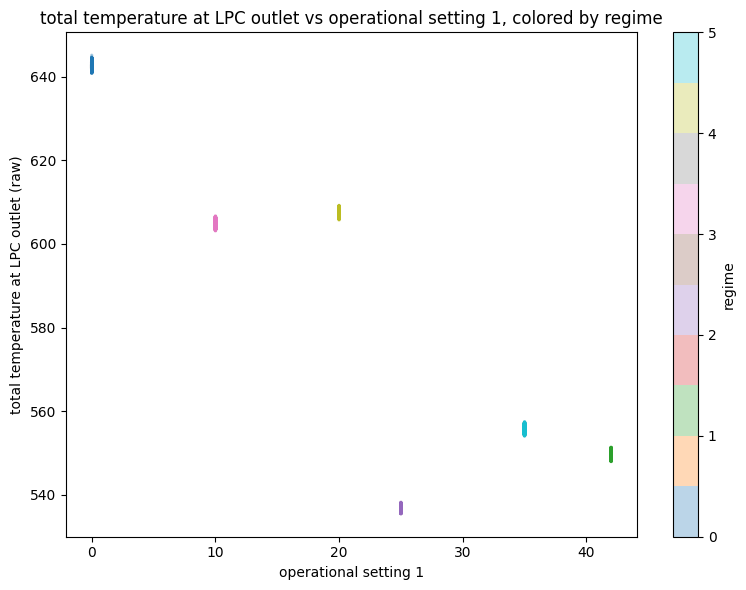

In [522]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    combined["operational setting 1"],
    combined["total temperature at LPC outlet"],
    c=combined["conditions"],
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel("operational setting 1")
ax.set_ylabel("total temperature at LPC outlet (raw)")
ax.set_title("total temperature at LPC outlet vs operational setting 1, colored by regime")

plt.colorbar(scatter, label="regime")
plt.tight_layout()
plt.show()

## Build the raw (unnormalized) X matrix

In [523]:
sensor_columns = columns[5:]

X_raw_unnorm = combined[sensor_columns].copy()

# Drop near-constant sensors
X_raw_unnorm = X_raw_unnorm.drop(columns=[
    "total temperature at fan inlet", "pressure at fan inlet",
    "demanded fan speed", "demanded corrected fan speed"
])

print(X_raw_unnorm.shape)
X_raw_unnorm.describe().T[["mean", "std"]]

(160359, 17)


,mean,std
total temperature at LPC outlet,597.361022,42.478516
total temperature at HPC outlet,1467.035653,118.175261
total temperature at LPT outlet,1260.956434,136.300073
pressure at bypass duct,14.424935,6.443922
total pressure at HPC outlet,359.729968,174.133835
physical fan speed,2273.829707,142.426613
physical core speed,8677.553696,374.657454
engine pressure ratio,1.153705,0.142103
static pressure at HPC outlet,44.212049,3.426342
ratio of fuel flow to Ps30,338.789821,164.193480


### Autoscale and run SVD (raw data)

In [524]:
X_raw_scaled = (X_raw_unnorm - X_raw_unnorm.mean()) / X_raw_unnorm.std()

U_raw, S_raw, Vt_raw = np.linalg.svd(X_raw_scaled, full_matrices=False)

T_raw = U_raw * S_raw   # scores
P_raw = Vt_raw.T        # loadings

explained_raw = (S_raw ** 2) / np.sum(S_raw ** 2)
print("Variance explained by first 5 PCs:", explained_raw[:5])

Variance explained by first 5 PCs: [0.87611875 0.10470467 0.01335819 0.00277345 0.00164942]


### Scree plot (raw PCA)

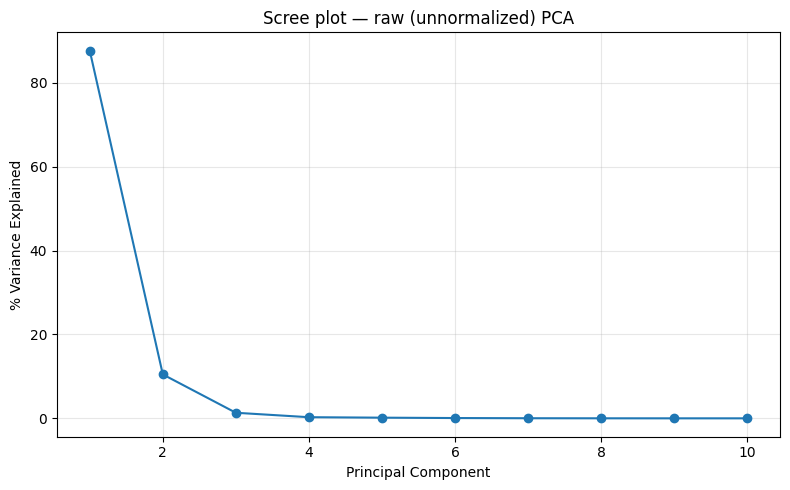

Cumulative variance explained:
[87.61187489 98.08234198 99.41816129 99.69550623 99.86044829 99.93719179
 99.96708574 99.98057866 99.98716304 99.99265947]


In [525]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
ax.plot(range(1, n_show + 1), explained_raw[:n_show] * 100, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree plot — raw (unnormalized) PCA")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Cumulative variance explained:")
print(np.cumsum(explained_raw[:n_show]) * 100)

### Scores plot (raw PCA), colored by dataset

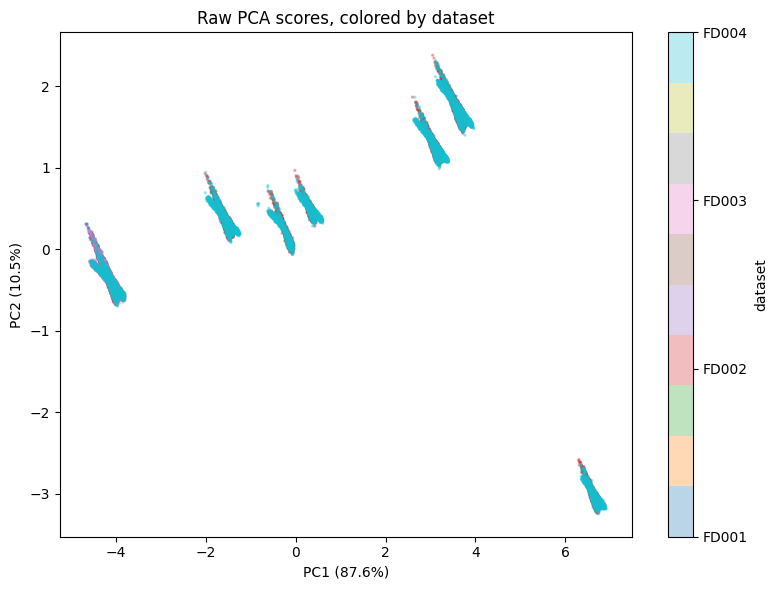

In [526]:
fig, ax = plt.subplots(figsize=(8, 6))

dataset_codes = combined["dataset"].astype("category").cat.codes
dataset_labels = combined["dataset"].astype("category").cat.categories

scatter = ax.scatter(
    T_raw[:, 0],
    T_raw[:, 1],
    c=dataset_codes,
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel(f"PC1 ({explained_raw[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_raw[1]*100:.1f}%)")
ax.set_title("Raw PCA scores, colored by dataset")

cbar = plt.colorbar(scatter, ticks=range(len(dataset_labels)))
cbar.ax.set_yticklabels(dataset_labels)
cbar.set_label("dataset")

plt.tight_layout()
plt.show()

**Observation:** PC1 alone explains ~87.6% of variance in the raw data, and the scores plot shows 6 tightly separated, non-overlapping clusters corresponding to operating condtions. Confirming that raw PCA is dominated by operating condition rather than engine degradation.

## After normalization: PCA on conditions-normalized data

In [527]:
condition_means = combined.groupby("conditions")[sensor_columns].transform("mean")
combined_normalized = combined.copy()
combined_normalized[sensor_columns] = combined[sensor_columns] - condition_means

combined_normalized[sensor_columns].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
total temperature at fan inlet,-6.101596e-15,1.759568e-14,-5.684342e-14,0.000000
total temperature at LPC outlet,-3.134277e-14,4.898674e-01,-1.765438e+00,2.544562
total temperature at HPC outlet,-8.677573e-16,6.322369e+00,-2.494986e+01,27.660142
total temperature at LPT outlet,1.474620e-16,8.926482e+00,-2.955972e+01,34.870279
pressure at fan inlet,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
pressure at bypass duct,3.432436e-16,1.330220e-02,-1.527444e-01,0.022467
total pressure at HPC outlet,4.957702e-15,1.986426e+00,-5.285404e+00,16.484612
physical fan speed,-9.036444e-14,1.957367e-01,-1.185408e+00,2.219195
physical core speed,1.203744e-13,1.864412e+01,-4.630849e+01,180.361508
engine pressure ratio,-5.375366e-17,3.801778e-03,-1.200826e-02,0.038541


### Build the X matrix (sensors only, no operational settings)

In [528]:
feature_columns = sensor_columns  # sensors only, no operational settings

X_raw = combined_normalized[feature_columns].copy()

stds = X_raw.std()
near_constant = stds[stds < 1e-6].index.tolist()
print("Dropping near-constant columns:", near_constant)

X_raw = X_raw.drop(columns=near_constant)

print(X_raw.shape)
X_raw.describe().T[["mean", "std"]]

Dropping near-constant columns: ['total temperature at fan inlet', 'pressure at fan inlet', 'demanded fan speed', 'demanded corrected fan speed']
(160359, 17)


,mean,std
total temperature at LPC outlet,-3.134277e-14,0.489867
total temperature at HPC outlet,-8.677573e-16,6.322369
total temperature at LPT outlet,1.474620e-16,8.926482
pressure at bypass duct,3.432436e-16,0.013302
total pressure at HPC outlet,4.957702e-15,1.986426
physical fan speed,-9.036444e-14,0.195737
physical core speed,1.203744e-13,18.644122
engine pressure ratio,-5.375366e-17,0.003802
static pressure at HPC outlet,-9.216376e-17,0.274977
ratio of fuel flow to Ps30,-1.307733e-14,1.858804


### Autoscale and run SVD (regime-normalized data)

In [529]:
X_norm_scaled = (X_raw - X_raw.mean()) / X_raw.std()

U_norm, S_norm, Vt_norm = np.linalg.svd(X_norm_scaled, full_matrices=False)

T_norm = U_norm * S_norm
P_norm = Vt_norm.T

explained_norm = (S_norm ** 2) / np.sum(S_norm ** 2)
print("Variance explained by first 5 PCs:", explained_norm[:5])

Variance explained by first 5 PCs: [0.33470994 0.29663369 0.08069254 0.05672065 0.0443339 ]


### Scree plot (regime-normalized PCA)

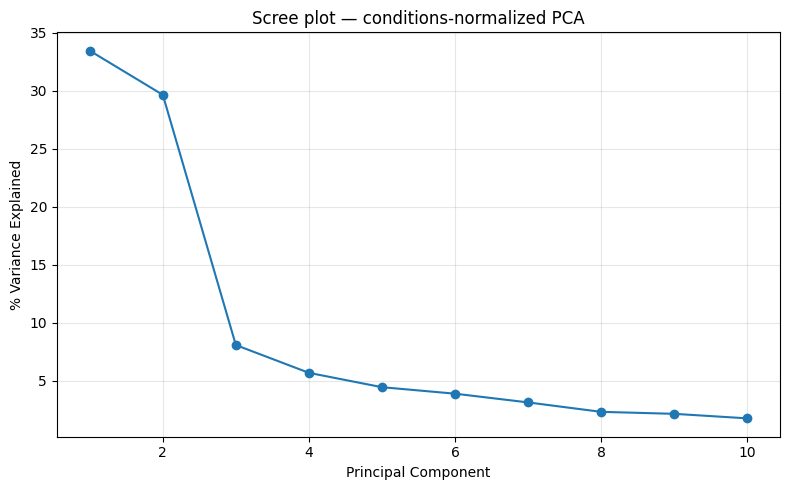

Cumulative variance explained:
[33.47099404 63.13436266 71.20361626 76.87568165 81.30907137 85.18192525
 88.30176148 90.60769379 92.7424622  94.48750444]


In [530]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
ax.plot(range(1, n_show + 1), explained_norm[:n_show] * 100, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree plot — conditions-normalized PCA")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Cumulative variance explained:")
print(np.cumsum(explained_norm[:n_show]) * 100)

### Scores plot (regime-normalized PCA), colored by dataset

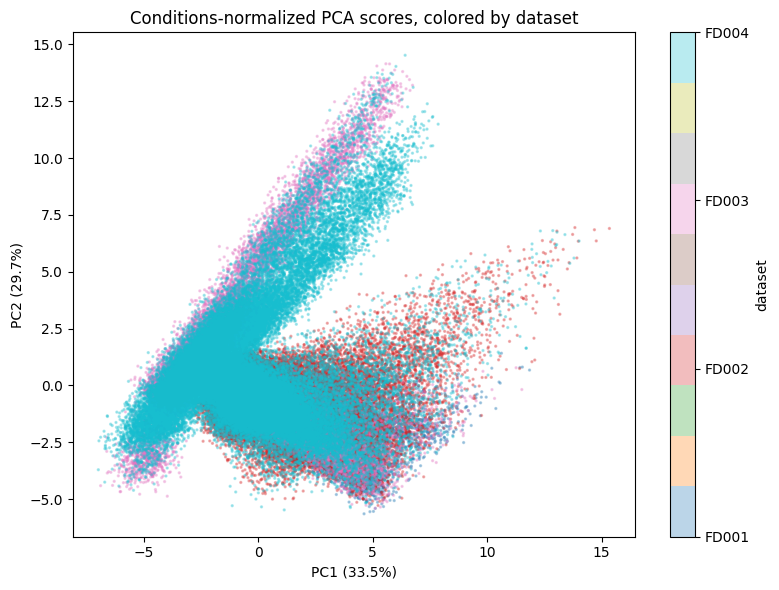

In [531]:
fig, ax = plt.subplots(figsize=(8, 6))

dataset_codes = combined["dataset"].astype("category").cat.codes
dataset_labels = combined["dataset"].astype("category").cat.categories

scatter = ax.scatter(
    T_norm[:, 0],
    T_norm[:, 1],
    c=dataset_codes,
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel(f"PC1 ({explained_norm[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_norm[1]*100:.1f}%)")
ax.set_title("Conditions-normalized PCA scores, colored by dataset")

cbar = plt.colorbar(scatter, ticks=range(len(dataset_labels)))
cbar.ax.set_yticklabels(dataset_labels)
cbar.set_label("dataset")

plt.tight_layout()
plt.show()

**Observation:** After condition normalization, PC1 drops to ~28.5% of variance and the 6 operating conditions clusters are no longer separated. Confirming the operating-condition confound has been removed. Instead, the scores form a branching shape: one arm reaching toward high PC2, another toward high PC1.

### Cumulative variance explained (condtions-normalized PCA)

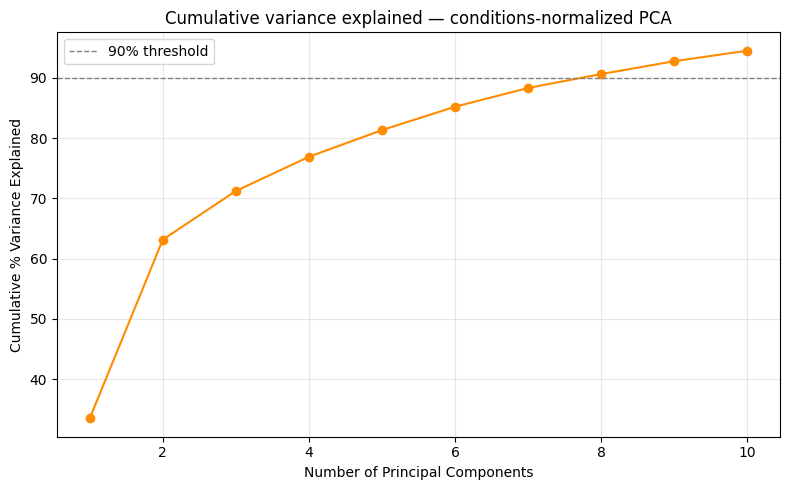

In [532]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
cumulative = np.cumsum(explained_norm[:n_show]) * 100

ax.plot(range(1, n_show + 1), cumulative, "o-", color="darkorange")
ax.axhline(90, color="grey", linestyle="--", linewidth=1, label="90% threshold")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative % Variance Explained")
ax.set_title("Cumulative variance explained — conditions-normalized PCA")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Quantifying which datasets populate each arm

In [533]:
scores_df = pd.DataFrame({
    "PC1": T_norm[:, 0],
    "PC2": T_norm[:, 1],
    "dataset": combined["dataset"].values,
})

upper_arm = scores_df[(scores_df["PC2"] > 7) & (scores_df["PC1"] < 5)]
lower_arm = scores_df[(scores_df["PC1"] > 5) & (scores_df["PC2"] < 5)]

print("Upper arm (high PC2) — dataset proportions:")
print(upper_arm["dataset"].value_counts(normalize=True).round(3))

print("\nLower-right arm (high PC1) — dataset proportions:")
print(lower_arm["dataset"].value_counts(normalize=True).round(3))

print("\nOverall dataset proportions (for reference):")
print(combined["dataset"].value_counts(normalize=True).round(3))

Upper arm (high PC2) — dataset proportions:
dataset
FD003    0.511
FD004    0.489
Name: proportion, dtype: float64

Lower-right arm (high PC1) — dataset proportions:
dataset
FD002    0.449
FD004    0.260
FD001    0.196
FD003    0.095
Name: proportion, dtype: float64

Overall dataset proportions (for reference):
dataset
FD004    0.382
FD002    0.335
FD003    0.154
FD001    0.129
Name: proportion, dtype: float64


**Observation:** the upper arm is populated almost exclusively by FD003/FD004 (both have fan + HPC degradation), while the lower-right arm leans toward FD001/FD002 (HPC-only degradation). Suggesting PC2 captures a fault-mode signature distinguishing single vs. dual degradation pathways.

### Biplot: conditions-normalized PCA scores and loadings

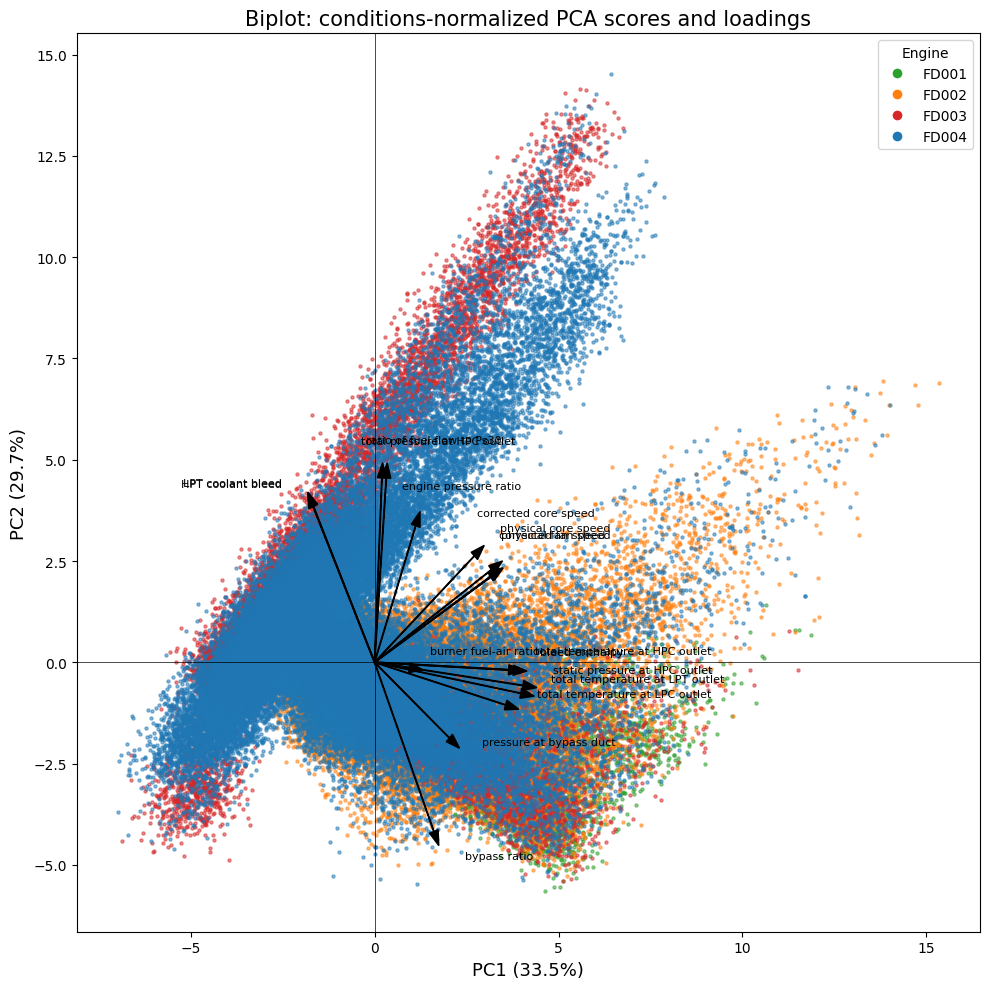

In [549]:
fd_labels = np.concatenate([
    np.repeat("FD001", len(train["FD001"])),
    np.repeat("FD002", len(train["FD002"])),
    np.repeat("FD003", len(train["FD003"])),
    np.repeat("FD004", len(train["FD004"]))
])

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 10))

fd_colors = {
    "FD001": "tab:green",
    "FD002": "tab:orange",
    "FD003": "tab:red",
    "FD004": "tab:blue"
}

for fd, color in fd_colors.items():

    mask = fd_labels == fd

    ax.scatter(
        T_norm[mask, 0],
        T_norm[mask, 1],
        s=5,
        alpha=0.5,
        color=color
    )

scale = np.max(np.abs(T_norm[:, :2])) * 0.8

for i, sensor in enumerate(X_raw.columns):

    x = P_norm[i, 0] * scale
    y = P_norm[i, 1] * scale

    ax.arrow(
        0,
        0,
        x,
        y,
        color="black",
        width=0.015,
        head_width=0.25,
        length_includes_head=True,
    )

    length = np.sqrt(x**2 + y**2)

    if length == 0:
        continue

    perp_x = -y / length
    perp_y = x / length

    offset = 0.05 * scale

    label_x = x * 1.08 + perp_x * offset
    label_y = y * 1.08 + perp_y * offset

    ha = "left" if x >= 0 else "right"
    va = "bottom" if y >= 0 else "top"

    ax.text(
        label_x,
        label_y,
        sensor,
        fontsize=8,
        color="black",
        ha=ha,
        va=va
    )

ax.set_xlabel(
    f"PC1 ({explained_norm[0] * 100:.1f}%)",
    fontsize=13
)

ax.set_ylabel(
    f"PC2 ({explained_norm[1] * 100:.1f}%)",
    fontsize=13
)

ax.set_title(
    "Biplot: conditions-normalized PCA scores and loadings",
    fontsize=15
)

ax.axhline(
    0,
    color="black",
    linewidth=0.5
)

ax.axvline(
    0,
    color="black",
    linewidth=0.5
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color,
        markersize=8,
        label=fd
    )
    for fd, color in fd_colors.items()
]

ax.legend(
    handles=legend_handles,
    title="Engine",
    loc="best",
    fontsize=10
)

plt.tight_layout()
plt.show()

### Correlation matrix of sensors (conditions-normalized)

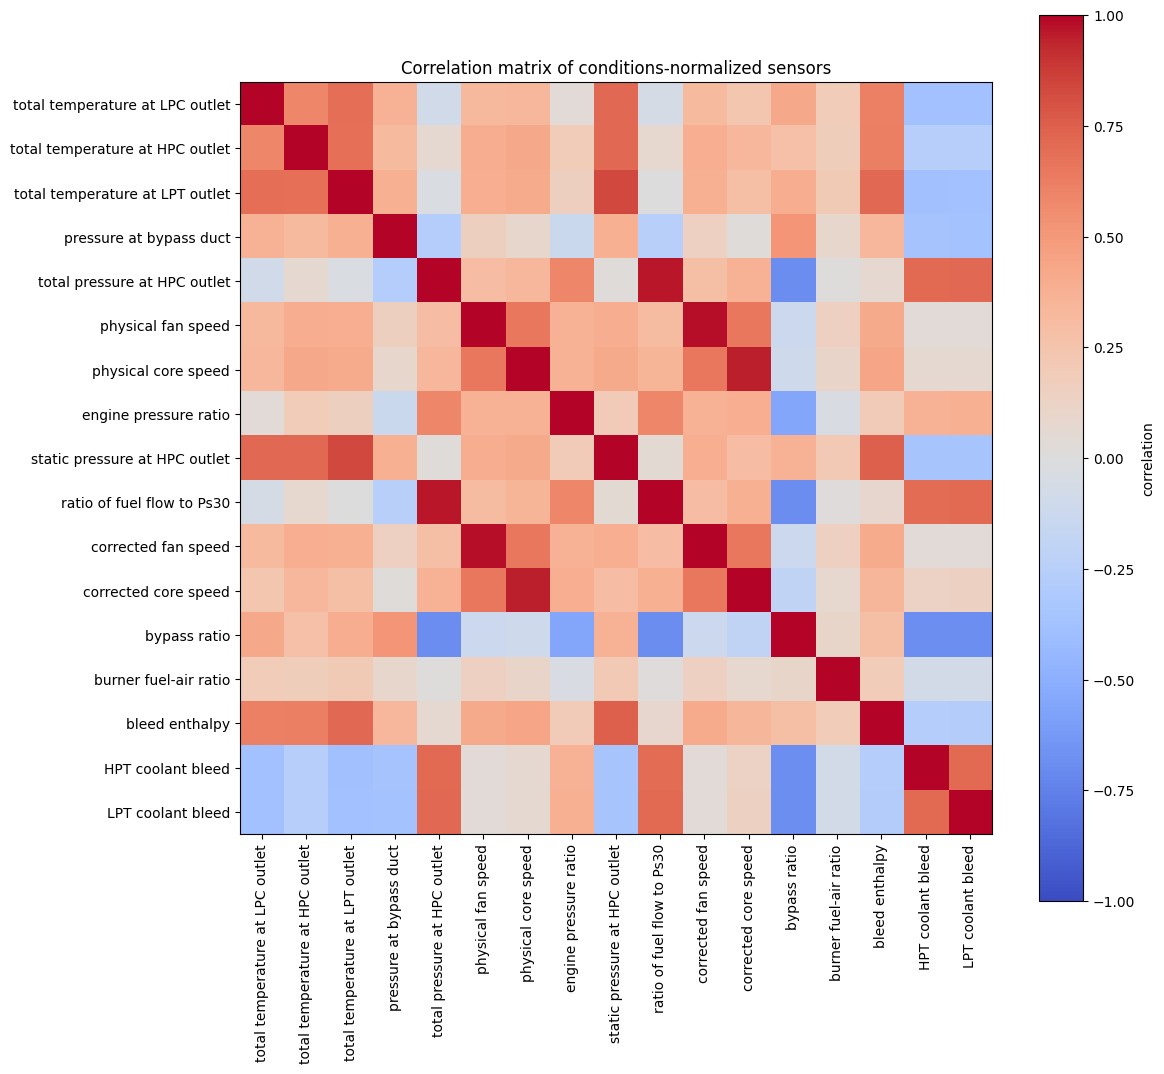

In [535]:
corr_matrix = X_raw.corr()

fig, ax = plt.subplots(figsize=(12, 11))

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

# Use the actual human-readable column names
ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    corr_matrix.columns
)

ax.set_title(
    "Correlation matrix of conditions-normalized sensors"
)

plt.colorbar(
    im,
    ax=ax,
    label="correlation"
)

plt.tight_layout()
plt.show()

Observation: sensors group into roughly 6-7 correlated blocks (e.g. S2/S3/S4/S11/S17; S8/S9/S13/S14; S7/S12; S20/S21), with S15 and S16 largely standalone, indicating substantial redundancy among the 17 sensors.

## Pretreatment plan

- **Centering and autoscaling:** All sensor variables are centered (mean subtracted) and scaled to unit variance before PCA, since sensors are on very different physical scales.
- **Constant/near-constant sensors:** Sensors with (near) zero variance (S1, S5, S18, S19) are dropped, as they carry no information and would cause division-by-zero issues during scaling.
- **Condition normalization:** FD002/FD004 operate across 6 changing flight conditions (unlike FD001/FD003's single condition), which confounds raw sensor readings with degradation. We cluster operating conditions via k-means and subtract each regime's mean from the sensors before PCA, removing this confound.
- **Operational settings excluded from PCA input:** Settings are only used to define regimes; including them directly in PCA would reintroduce the condition-driven variation we just removed.


## Data pretreatment

In [536]:
sensor_columns = columns[5:]
setting_columns = columns[2:5]

# Training RUL: final observed Unit cycle minus current Unit cycle.
def add_training_rul(df, engine):
    out = df.sort_values(['unit number', 'time in cycles']).copy()
    out['RUL'] = out.groupby('unit number')['time in cycles'].transform('max') - out['time in cycles']
    out['Engine'] = engine
    out['Unit'] = out['unit number']
    out['Unit cycle'] = out['time in cycles']
    return out

train_prepared = {fd: add_training_rul(train[fd], fd) for fd in train}

# Split by complete Units, never by rows, so cycles from one Unit cannot leak
# between calibration and validation. Both partitions retain their RUL values.
from sklearn.model_selection import train_test_split
calibration, validation = {}, {}
for fd, data in train_prepared.items():
    units = data['Unit'].drop_duplicates()
    cal_units, val_units = train_test_split(units, test_size=.2, random_state=42)
    calibration[fd] = data[data['Unit'].isin(cal_units)].copy()
    validation[fd] = data[data['Unit'].isin(val_units)].copy()
    print(f'{fd}: calibration Units={len(cal_units)}, validation Units={len(val_units)}, RUL missing={data["RUL"].isna().sum()}')

FD001: calibration Units=80, validation Units=20, RUL missing=0
FD002: calibration Units=208, validation Units=52, RUL missing=0
FD003: calibration Units=80, validation Units=20, RUL missing=0
FD004: calibration Units=199, validation Units=50, RUL missing=0


### Removal of constant variables

In [537]:
pretreatment = {}

variance_threshold = 1e-8

for fd in train:

    variances = train[fd][sensor_columns].var()

    dropped = variances[
        variances <= variance_threshold
    ].index.tolist()

    features = [
        c for c in sensor_columns
        if c not in dropped
    ]

    pretreatment[fd] = {
        "features": features,
        "dropped_low_variance": dropped
    }

    print(
        f"{fd}: retained {len(features)} sensors"
    )

    print(
        f"{fd}: dropped {dropped}"
    )

FD001: retained 15 sensors
FD001: dropped ['total temperature at fan inlet', 'pressure at fan inlet', 'engine pressure ratio', 'burner fuel-air ratio', 'demanded fan speed', 'demanded corrected fan speed']
FD002: retained 21 sensors
FD002: dropped []
FD003: retained 16 sensors
FD003: dropped ['total temperature at fan inlet', 'pressure at fan inlet', 'burner fuel-air ratio', 'demanded fan speed', 'demanded corrected fan speed']
FD004: retained 21 sensors
FD004: dropped []


### Centering and autoscaling

In [538]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Condition-normalize all retained sensors, but keep every valid Unit cycle.
condition_means = combined.groupby('conditions')[sensor_columns].mean()
pretreatment_data, scaled_train, pca_results = {}, {}, {}
extreme_summary = []
for fd in train:
    features = pretreatment[fd]['features']
    data = train_prepared[fd].copy()
    data['conditions'] = kmeans.predict(data[setting_columns])
    regime_means = condition_means.loc[data['conditions']].to_numpy()
    data[sensor_columns] = data[sensor_columns].to_numpy() - regime_means
    # Diagnose IQR extremes for reporting, but retain them as possible degradation signals.
    q1, q3 = data[features].quantile(.25), data[features].quantile(.75)
    iqr = q3 - q1
    extreme_rows = (data[features].lt(q1 - 1.5 * iqr) | data[features].gt(q3 + 1.5 * iqr)).any(axis=1)
    extreme_summary.append({'Engine': fd, 'flagged Unit cycles': int(extreme_rows.sum()), 'flagged %': round(100 * extreme_rows.mean(), 2)})
    pretreatment_data[fd] = data
    scaler = StandardScaler()
    X = scaler.fit_transform(data[features])
    scaled_train[fd] = pd.DataFrame(X, columns=features, index=data.index)
    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(scaled_train[fd])
    pca_results[fd] = {'scaler': scaler, 'pca': pca, 'scores': scores}
    print(f'{fd}: max |mean|={scaled_train[fd].mean().abs().max():.2e}, mean std={scaled_train[fd].std().mean():.3f}')
display(pd.DataFrame(extreme_summary))

FD001: max |mean|=5.18e-16, mean std=1.000
FD002: max |mean|=1.31e-16, mean std=0.857
FD003: max |mean|=7.59e-17, mean std=1.000
FD004: max |mean|=1.14e-16, mean std=0.857


,Engine,flagged Unit cycles,flagged %
0,FD001,2844,13.79
1,FD002,23712,44.11
2,FD003,4833,19.55
3,FD004,30937,50.51


### Visualisation (Bi-plots)

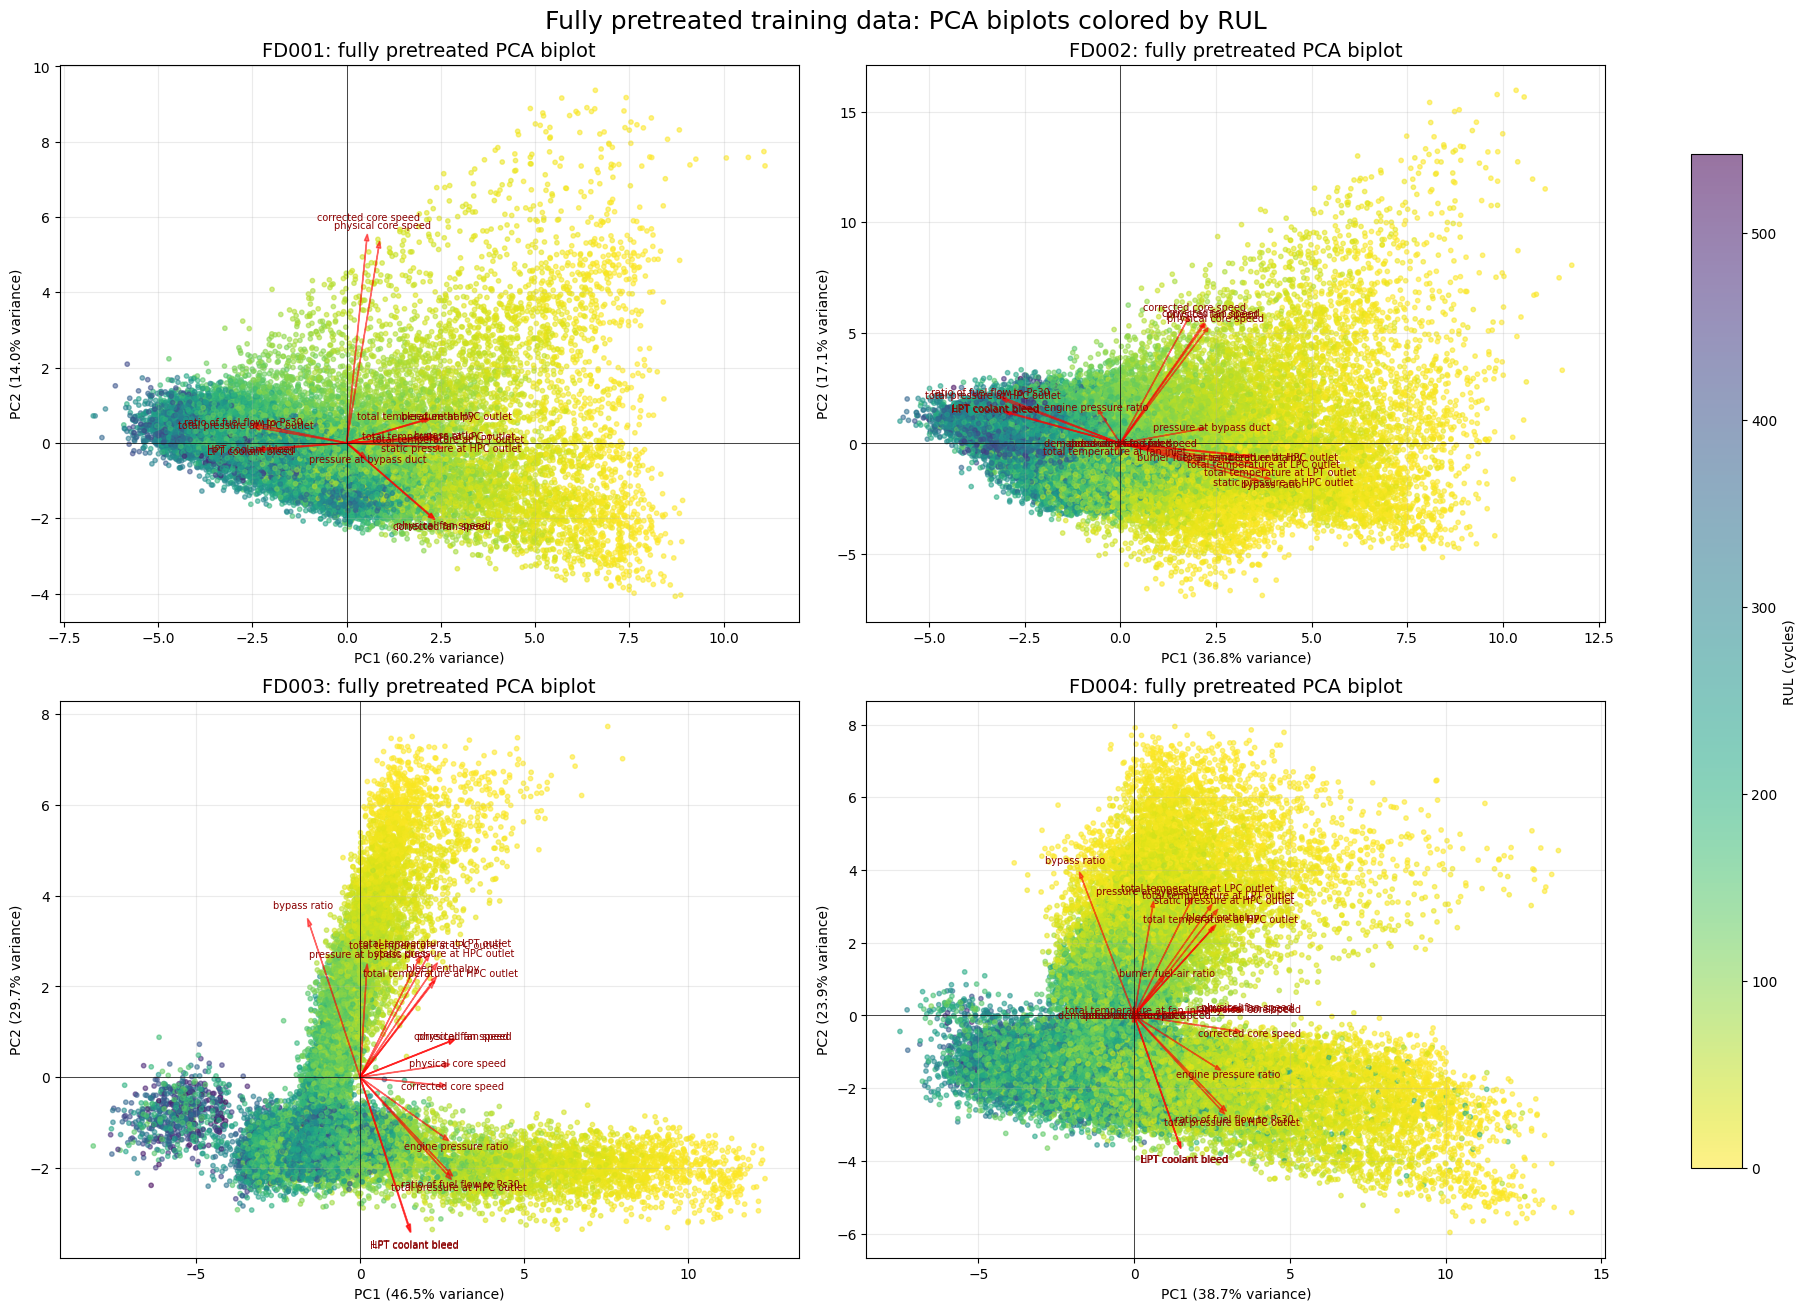

In [539]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)
for ax, fd in zip(axes.flat, train):
    result = pca_results[fd]
    pca, scores = result['pca'], result['scores']
    data = pretreatment_data[fd]
    points = ax.scatter(scores[:, 0], scores[:, 1], c=data['RUL'], cmap='viridis_r', s=10, alpha=.55)
    scale = np.max(np.abs(scores)) * .75
    for j, sensor in enumerate(pretreatment[fd]['features']):
        x, y = pca.components_[:2, j] * scale
        ax.arrow(0, 0, x, y, color='red', alpha=.55, width=.008, head_width=.12, length_includes_head=True)
        ax.text(x * 1.08, y * 1.08, sensor, color='darkred', fontsize=7, ha='center', va='center')
    ax.set_title(f'{fd}: fully pretreated PCA biplot', fontsize=14)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
    ax.axhline(0, color='black', linewidth=.5)
    ax.axvline(0, color='black', linewidth=.5)
    ax.grid(alpha=.25)
fig.colorbar(points, ax=axes.ravel().tolist(), label='RUL (cycles)', shrink=.85)
fig.suptitle('Fully pretreated training data: PCA biplots colored by RUL', fontsize=18)
plt.show()